# EDA for PPG Leader

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import os


In [2]:
# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
os.makedirs(PROCESSED_PATH, exist_ok=True)

The first phase of EDA will be to determine which categories matter most for the DPOY award

In [3]:
# Importing the merged data set from notebook 01
players_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [4]:
# Previewing the data to ensure this is the correct DataFrame
players_df.head(5)

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,WS,WS/48,OBPM,DBPM,BPM,VORP,is_MVP,is_DPOY,is_PPG_Leader,Season
0,Kevin Durant,21.0,OKC,SF,82.0,82.0,39.5,9.7,20.3,0.476,...,16.1,0.238,6.3,0.8,7.1,7.5,False,False,True,2010
1,LeBron James,25.0,CLE,SF,76.0,76.0,39.0,10.1,20.1,0.503,...,18.5,0.299,9.1,2.8,11.8,10.3,True,False,False,2010
2,Carmelo Anthony,25.0,DEN,SF,69.0,69.0,38.2,10.0,21.8,0.458,...,7.9,0.145,3.5,-1.2,2.3,2.9,False,False,False,2010
3,Kobe Bryant,31.0,LAL,SG,73.0,73.0,38.8,9.8,21.5,0.456,...,9.4,0.160,3.9,0.2,4.1,4.4,False,False,False,2010
4,Dwyane Wade,28.0,MIA,SG,77.0,77.0,36.3,9.3,19.6,0.476,...,13.0,0.224,7.1,2.1,9.2,7.9,False,False,False,2010


In [5]:
# Dropping other award categories
columns_to_drop = ["is_MVP", "is_DPOY"]
players_df.drop(columns=columns_to_drop, inplace=True)

In [6]:
# Setting is_PPG_Leader column to 0/1
players_df["is_PPG_Leader"] = players_df["is_PPG_Leader"].astype(int)

In [7]:
numeric_cols = players_df.select_dtypes(include=["number"]).columns
player_corr_matrix = players_df[numeric_cols].corr()

In [8]:
ppg_corr = player_corr_matrix["is_PPG_Leader"].drop("is_PPG_Leader").sort_values(ascending=False)
print(ppg_corr)

VORP      0.225021
FT        0.208417
FTA       0.190204
OWS       0.188057
WS        0.168660
PPG       0.153728
TOV       0.136040
FG        0.129855
FGA       0.127844
USG%      0.120948
2P        0.111565
2PA       0.109271
3P        0.101090
DWS       0.099279
3PA       0.099060
PER       0.096525
DRB       0.088484
AST       0.088134
OBPM      0.084152
STL       0.079826
BPM       0.077828
GS        0.076147
AST%      0.072933
TRB       0.072409
MP        0.069953
WS/48     0.064565
BLK       0.042880
PF        0.042204
G         0.041097
FT%       0.034681
TS%       0.031821
FTr       0.031746
DRB%      0.029682
DBPM      0.029347
ORB       0.021275
3P%       0.019978
TRB%      0.016844
eFG%      0.016085
STL%      0.015659
FG%       0.013019
2P%       0.012830
BLK%      0.005463
Age       0.005207
3PAr      0.001992
TOV%     -0.002182
Season   -0.003339
ORB%     -0.009456
Name: is_PPG_Leader, dtype: float64


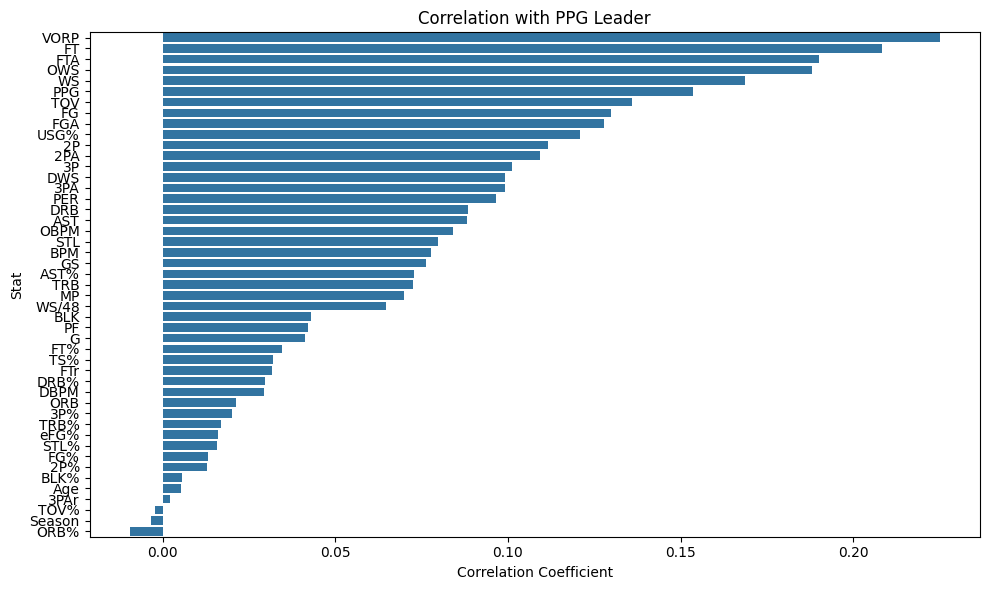

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x=ppg_corr.values, y=ppg_corr.index)
plt.title("Correlation with PPG Leader")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Stat")
plt.tight_layout()
plt.show()

Based on the results here, we're going to take everything with a correlation coefficient >.10

In [10]:
important_stats = ppg_corr[ppg_corr > 0.10].index

In [11]:
ppg_eda = players_df[list(important_stats) + ["is_PPG_Leader"]]

In [12]:
print(ppg_eda.head())
print(f"{ppg_eda.shape[1]-1} stats selected with correlation > 0.10")

   VORP   FT   FTA   OWS    WS   PPG  TOV    FG   FGA  USG%   2P   2PA   3P  \
0   7.5  9.2  10.2  11.1  16.1  30.1  3.3   9.7  20.3  32.0  8.1  16.1  1.6   
1  10.3  7.8  10.2  13.3  18.5  29.7  3.4  10.1  20.1  33.5  8.4  15.0  1.7   
2   2.9  7.4   8.9   5.6   7.9  28.2  3.0  10.0  21.8  33.4  9.1  19.1  0.9   
3   4.4  6.0   7.4   5.4   9.4  27.0  3.2   9.8  21.5  32.3  8.5  17.4  1.4   
4   7.9  6.9   9.1   8.5  13.0  26.6  3.3   9.3  19.6  34.9  8.4  16.5  0.9   

   is_PPG_Leader  
0              1  
1              0  
2              0  
3              0  
4              0  
13 stats selected with correlation > 0.10


Now that we know the correlation between individual stats and the PPG Leader, we're going to check for correlation between individual stats and reduce redundancies

In [13]:
# Select numeric feature columns excluding the target (PPG Leader)
features_only = ppg_eda.drop(columns=["is_PPG_Leader"])

In [14]:
# Compute the correlation matrix with absolute values
corr = features_only.corr().abs()

In [15]:
# Convert correlation to disatance (1 - correlation)
distance_matrix = 1 - corr

In [16]:
# Use hierarchical clustering (linkage) on the distance matrix
linkage_matrix = linkage(distance_matrix, method="ward")

C:\Users\bartl\AppData\Local\Temp\ipykernel_2944\187123466.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method="ward")


Plotting and using a dendrogram to determine correlation between columns. Features are joined closer to the left are more correlated

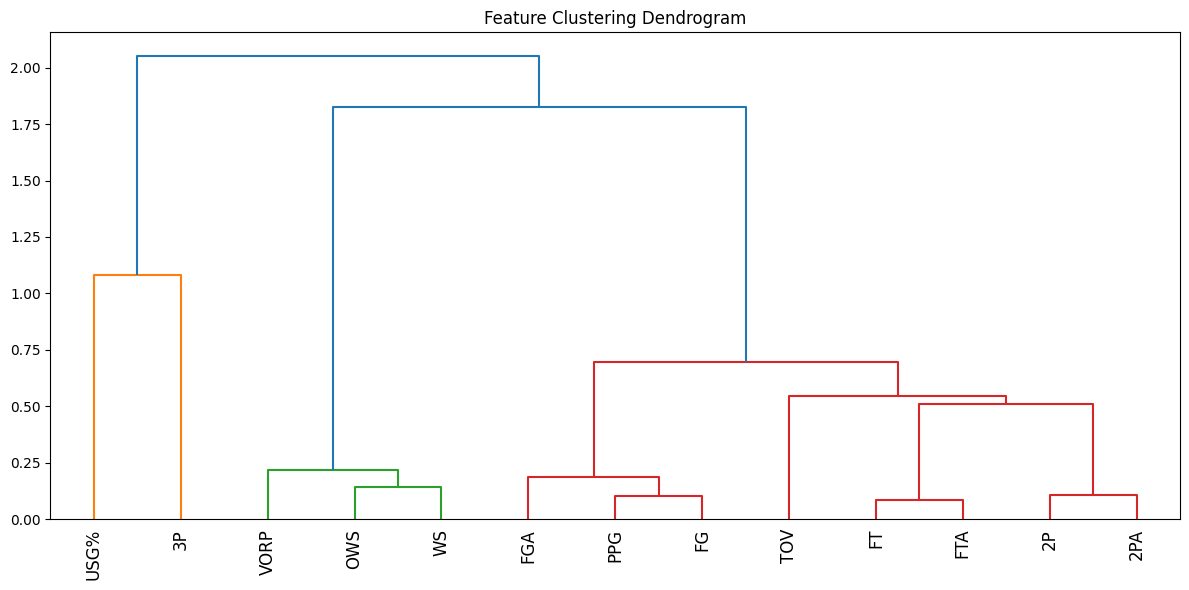

In [17]:
# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=corr.columns, leaf_rotation=90)
plt.title("Feature Clustering Dendrogram")
plt.tight_layout()
plt.show()

In [18]:
feature_corr = ppg_eda.drop(columns=["is_PPG_Leader"]).corr()

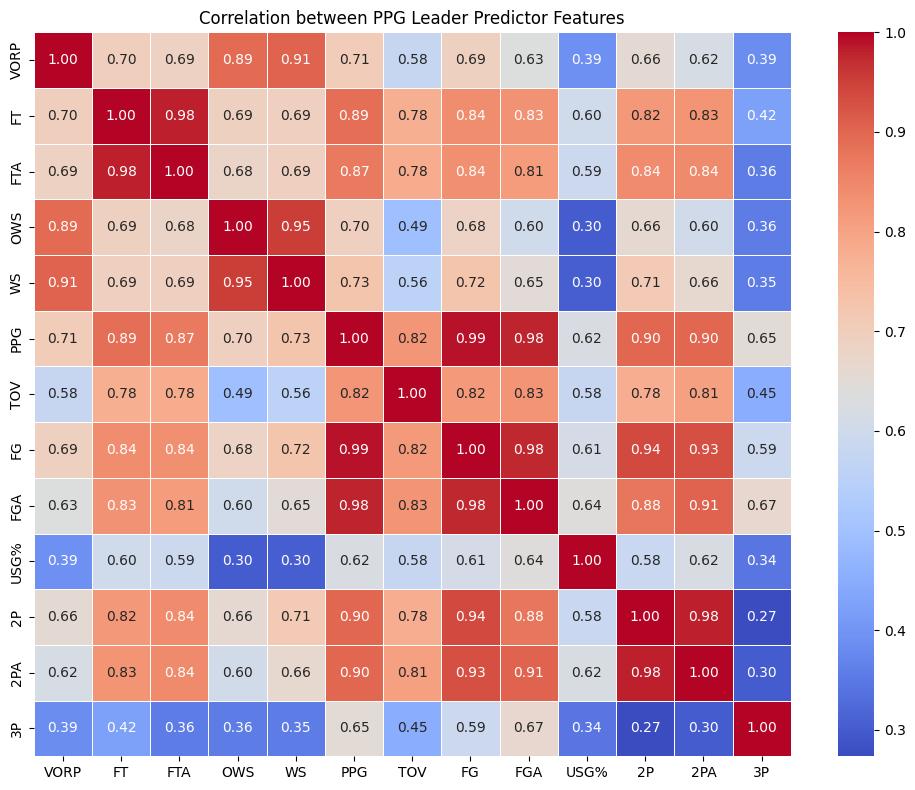

In [19]:
# Visualizing the data using a Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation between PPG Leader Predictor Features")
plt.tight_layout()
plt.show()

In [20]:
# Creating a correlation matrix of absolute values
corr_matrix = ppg_eda.drop(columns=["is_PPG_Leader"]).corr().abs()

In [21]:
# Selecting the upper triangle to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [22]:
# Finding highly correlated feature pairs (pairs over >.85)
high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.85)
]
print(f"Features to consider droppong due to high correlation: \n{high_corr_features}")

Features to consider droppong due to high correlation: 
['FTA', 'OWS', 'WS', 'PPG', 'FG', 'FGA', '2P', '2PA']


Based on domain knowledge, we're not going to go with the recommended features to drop. The PPG Leader in any given season is determine mainly by the total number of points scored across all games appeared in. So factors leading to the total number of points scored such as 2P or PPG are significant and should not be dropped.

In [23]:
dropping = ["OWS", "2PA", "FGA", "FTA"]
reduced_df = ppg_eda.drop(columns=dropping)

In [24]:
reduced_df.head(5)

,VORP,FT,WS,PPG,TOV,FG,USG%,2P,3P,is_PPG_Leader
0,7.5,9.2,16.1,30.1,3.3,9.7,32.0,8.1,1.6,1
1,10.3,7.8,18.5,29.7,3.4,10.1,33.5,8.4,1.7,0
2,2.9,7.4,7.9,28.2,3.0,10.0,33.4,9.1,0.9,0
3,4.4,6.0,9.4,27.0,3.2,9.8,32.3,8.5,1.4,0
4,7.9,6.9,13.0,26.6,3.3,9.3,34.9,8.4,0.9,0


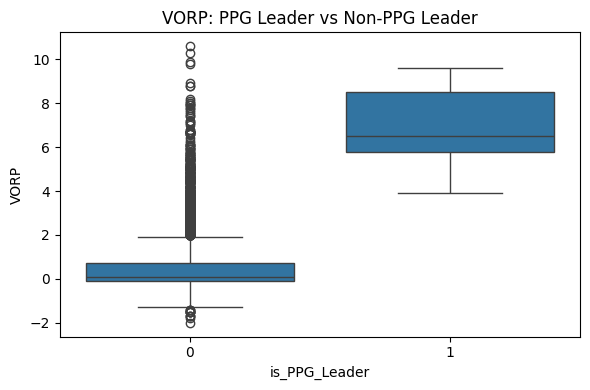

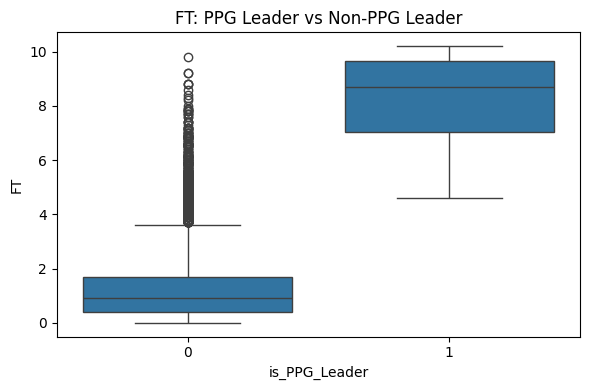

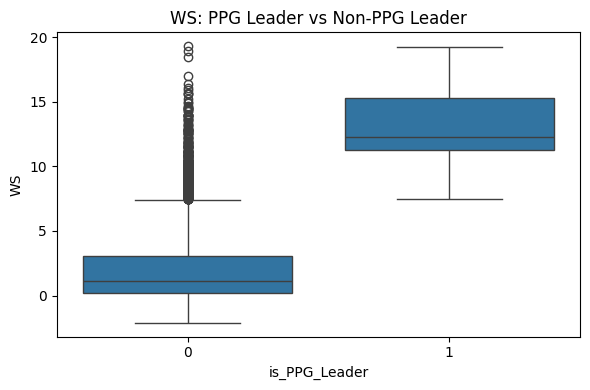

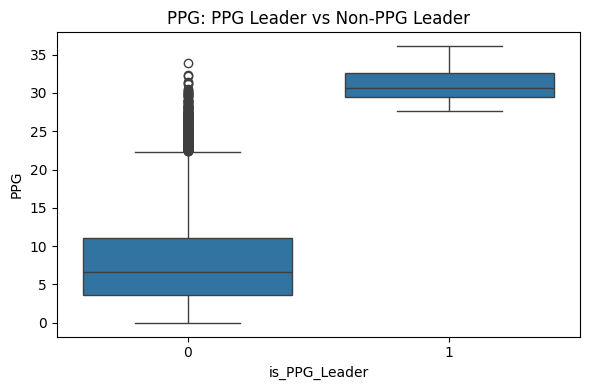

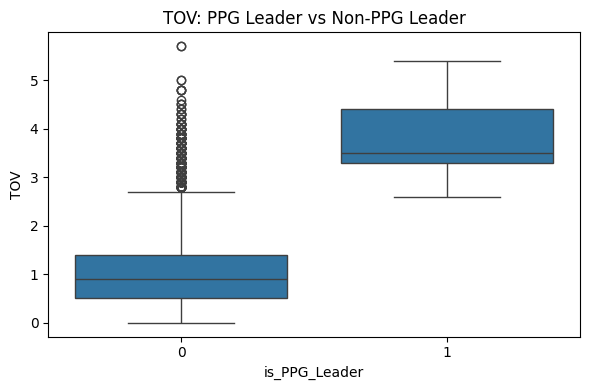

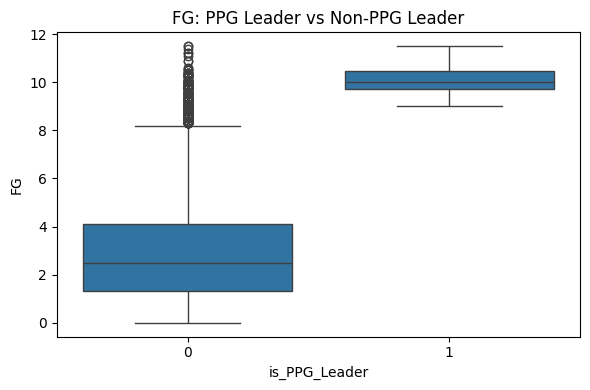

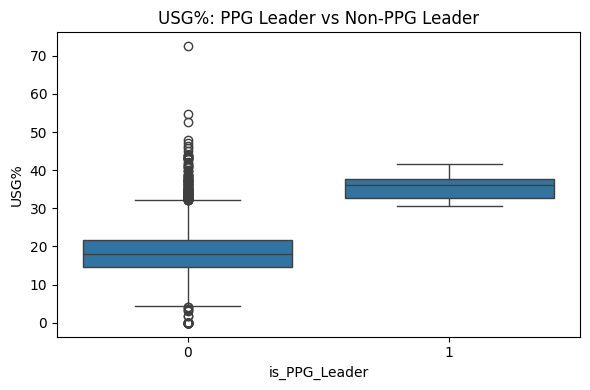

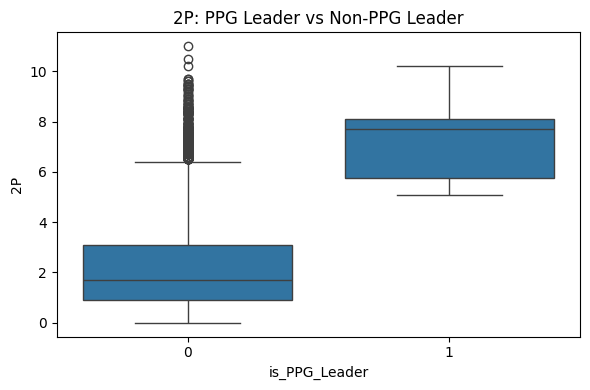

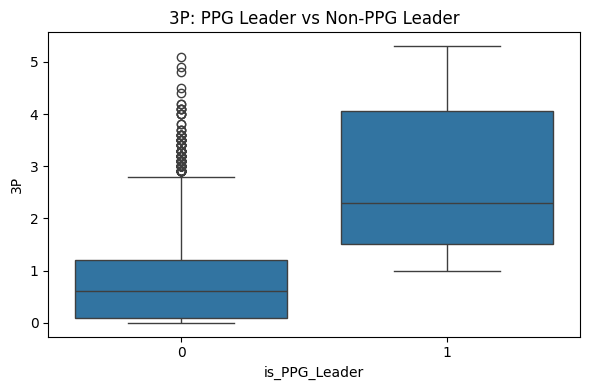

In [26]:
# Visualizing PPG Leader vs Non-PPG Leader for Key Features (0 = Non-PPG Leader, 1 = PPG Leader)
for col in reduced_df.columns:
    if col != "is_PPG_Leader":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="is_PPG_Leader", y=col, data=reduced_df)
        plt.title(f"{col}: PPG Leader vs Non-PPG Leader")
        plt.tight_layout()
        plt.show()

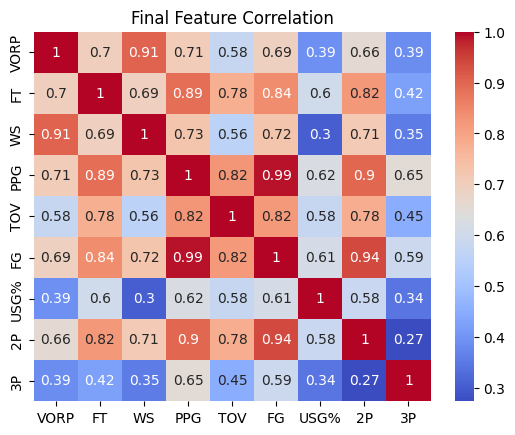

In [28]:
# One last check for redundancy
sns.heatmap(reduced_df.drop(columns="is_PPG_Leader").corr(), annot=True, cmap="coolwarm")
plt.title("Final Feature Correlation")
plt.show()

In [29]:
# Dropping 2P since it is so closely correlated with FTA
last_drop = ["2P", "FT", "WS"]
ppg_eda.drop(columns=last_drop)

,VORP,FTA,OWS,PPG,TOV,FG,FGA,USG%,2PA,3P,is_PPG_Leader
0,7.5,10.2,11.1,30.1,3.3,9.7,20.3,32.0,16.1,1.6,1
1,10.3,10.2,13.3,29.7,3.4,10.1,20.1,33.5,15.0,1.7,0
2,2.9,8.9,5.6,28.2,3.0,10.0,21.8,33.4,19.1,0.9,0
3,4.4,7.4,5.4,27.0,3.2,9.8,21.5,32.3,17.4,1.4,0
4,7.9,9.1,8.5,26.6,3.3,9.3,19.6,34.9,16.5,0.9,0
...,...,...,...,...,...,...,...,...,...,...,...
9711,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.8,0.5,0.0,0
9712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9714,0.0,0.0,0.0,0.0,0.0,0.0,0.5,21.6,0.5,0.0,0


In [30]:
reduced_df.to_csv(f"{PROCESSED_PATH}/ppg_eda_cleaned.csv")
print(f"ppg_eda_cleaned saved to {PROCESSED_PATH}")

ppg_eda_cleaned saved to ../../data/processed
